In [2]:
library(ggplot2)
library(openxlsx)
library(dplyr)
library(tidyr)
library(Seurat)
library(tibble)
library(tidyverse)
library(ggpubr)
library(cowplot)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.1.6
✔ lubridate 1.9.4     ✔ stringr   1.6.0
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘cowplot’


The following object is masked from ‘package:ggpubr’:

    get_legend


The following object is masked from ‘package:lubridate’:

    stamp




In [3]:
obj_path = "/home/liyanguo/MyImmuCell/06_Finnal_raw_count/"

In [4]:
Level_counts_frac = read.xlsx("/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L4_donor_counts_frac_clinicl_table.xlsx",
                              rowNames=T)

# 细胞比例

In [5]:
cell_types = c('Core.NDNs#',
               'IRF1-.GBP2-.NDNs#',
                'IFIT2-.RNF213-.NDNs#',
               'VIM-.FLNA-.NDNs#',
               'CXCL8-.PTGS2+.NDNs#',
                'FOS-.NDNs#',
               'MT-ATP6-.MT-CO2-.NDNs#',
               'ALPL-.MARCKS-.NDNs#',
               'RGS2-.NDNs#'
)

In [6]:
Level_counts_frac_long = Level_counts_frac %>%
    select(ClinicalID,
       Ten_year_intervals,all_of(cell_types)) %>%
    pivot_longer(
      cols = -c(ClinicalID, Ten_year_intervals),
      names_to = "groupby",
      values_to = "groupby_count"
    ) %>%
    mutate(
      Ten_year_intervals = factor(Ten_year_intervals, levels = c('2-9','10-19','20-29','30-39','40-49','50-59','60-69','70-79','80-89','90+')),
      groupby = factor(groupby,levels =  cell_types)
    )

In [7]:
Level_counts_frac_long %>% 
    select(ClinicalID,groupby,groupby_count,Ten_year_intervals)  %>% 
    with_groups(
    .groups = ClinicalID,
    .f = ~ mutate(
      .x,
      proportion = groupby_count / sum(groupby_count, na.rm = TRUE) *100
    )
  )%>% 
    group_by(groupby) %>% 
    summarise(
    Mean_Ratio = mean(proportion, na.rm = TRUE),
    Std_Ratio = sd(proportion, na.rm = TRUE),
    N = n(),
    .groups = "drop"
  )

groupby,Mean_Ratio,Std_Ratio,N
<fct>,<dbl>,<dbl>,<int>
Core.NDNs#,40.485853,8.671061,994
IRF1-.GBP2-.NDNs#,10.894250,5.322606,994
IFIT2-.RNF213-.NDNs#,5.117578,3.768154,994
VIM-.FLNA-.NDNs#,7.829018,3.752829,994
CXCL8-.PTGS2+.NDNs#,4.609194,3.110315,994
FOS-.NDNs#,4.360992,2.575311,994
MT-ATP6-.MT-CO2-.NDNs#,10.659620,5.877480,994
ALPL-.MARCKS-.NDNs#,8.415947,3.489078,994
RGS2-.NDNs#,7.627547,2.992781,994


In [8]:
data_proportion = Level_counts_frac_long %>% 
    select(ClinicalID,groupby,groupby_count,Ten_year_intervals)  %>% 
    with_groups(
    .groups = ClinicalID,
    .f = ~ mutate(
      .x,
      proportion = groupby_count / sum(groupby_count, na.rm = TRUE) *100
    )
  )%>% 
    group_by(Ten_year_intervals, groupby) %>% 
    summarise(
    Mean_Ratio = mean(proportion, na.rm = TRUE),
    Std_Ratio = sd(proportion, na.rm = TRUE),
    N = n(),
    .groups = "drop"
  )

In [9]:
data_proportion

Ten_year_intervals,groupby,Mean_Ratio,Std_Ratio,N
<fct>,<fct>,<dbl>,<dbl>,<int>
2-9,Core.NDNs#,38.629710,7.967069,54
2-9,IRF1-.GBP2-.NDNs#,9.788496,5.397915,54
2-9,IFIT2-.RNF213-.NDNs#,4.957729,4.198417,54
2-9,VIM-.FLNA-.NDNs#,8.210229,4.478852,54
2-9,CXCL8-.PTGS2+.NDNs#,4.572710,3.261900,54
2-9,FOS-.NDNs#,5.390780,2.702732,54
2-9,MT-ATP6-.MT-CO2-.NDNs#,11.685058,5.532189,54
2-9,ALPL-.MARCKS-.NDNs#,9.017656,4.480068,54
2-9,RGS2-.NDNs#,7.747631,2.545817,54


In [10]:
all_colour=c("#6495ED","#D1352B","#D2EBC8","#D877B4","#EE934E","#5DA086","#e8df9a","#f0c1f5","#AED0DF")

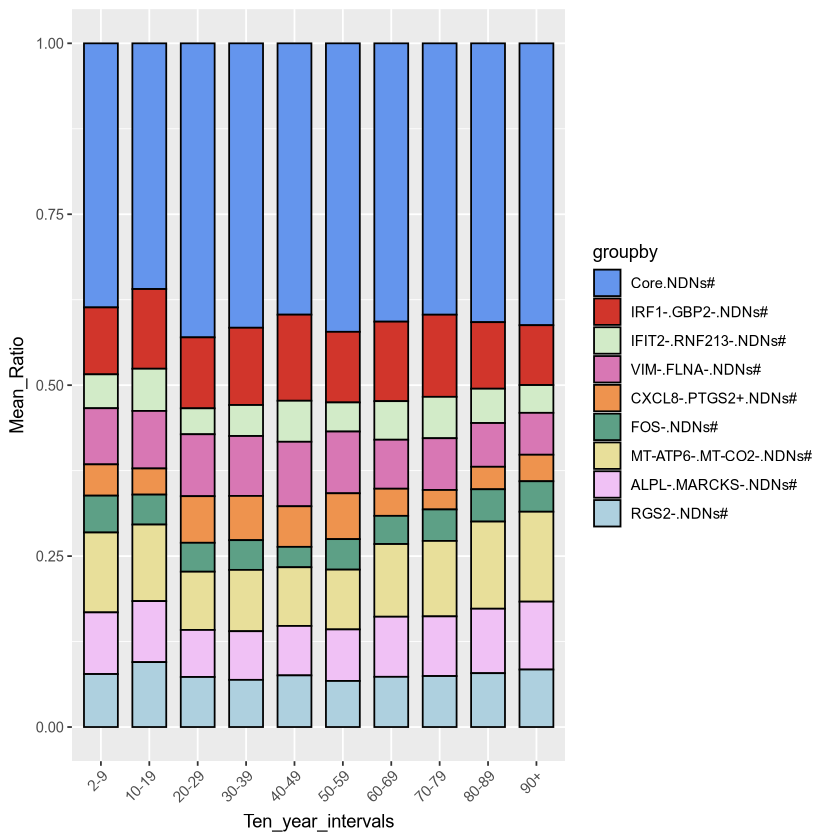

In [11]:
p = ggplot(data_proportion,aes(x = Ten_year_intervals, y = Mean_Ratio, fill = groupby)) + 
    geom_bar(stat="identity",position="fill", color="black", width=0.7) + scale_fill_manual(values = all_colour)+rotate_x_text(angle = 45)
p

In [12]:
ggsave2('/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L3/NDNs/Prop.pdf',p,width = 6,height = 6)

# Olink IFNG high and low

In [13]:
npx <- read.xlsx(
  "/home/liyanguo/MyImmuCell/10_olink/Olink_Target_96_Inflammation_v.3027.xlsx",
  sheet = "Npx",rowNames = T
) %>% select(-c("Plate.ID", "QC.Warning"))

In [14]:
colnames(npx)[11] = 'LAP TGF-beta-1'

In [15]:
var <- read.xlsx(
  "/home/liyanguo/MyImmuCell/10_olink/Olink_Target_96_Inflammation_v.3027.xlsx",
  sheet = "var",  rowNames =T
)

In [16]:
lod <- read.xlsx(
  "/home/liyanguo/MyImmuCell/10_olink/Olink_Target_96_Inflammation_v.3027.xlsx",
  sheet = "LOD", rowNames =T
)

In [17]:
valid_p <- rownames(subset(lod,lod$Missing.Data.freq.<0.25))

In [18]:
npx_filtered <- npx[,c('ClinicalID',valid_p)]

In [19]:
Level_counts_frac = read.xlsx("/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L4_donor_counts_frac_clinicl_table.xlsx",
                              rowNames=T)

In [20]:
cell_types = c('Core.NDNs#',
               'IRF1-.GBP2-.NDNs#',
                'IFIT2-.RNF213-.NDNs#',
               'VIM-.FLNA-.NDNs#',
               'CXCL8-.PTGS2+.NDNs#',
                'FOS-.NDNs#',
               'MT-ATP6-.MT-CO2-.NDNs#',
               'ALPL-.MARCKS-.NDNs#',
               'RGS2-.NDNs#'
)

In [22]:
Level_counts_frac_long = Level_counts_frac %>%
    select(ClinicalID,
       Ten_year_intervals,all_of(cell_types)) %>%
    pivot_longer(
      cols = -c(ClinicalID, Ten_year_intervals),
      names_to = "groupby",
      values_to = "groupby_count"
    )

In [23]:
data_proportion = Level_counts_frac_long %>% 
    select(ClinicalID,groupby,groupby_count,Ten_year_intervals)  %>% 
    with_groups(
    .groups = ClinicalID,
    .f = ~ mutate(
      .x,
      proportion = groupby_count / sum(groupby_count, na.rm = TRUE) *100
    )
  )

In [24]:
data_proportion = left_join(data_proportion,npx_filtered[,c('ClinicalID','IFN-gamma')],by = 'ClinicalID')

In [25]:
data = data_proportion[,c('ClinicalID','groupby','Ten_year_intervals','proportion','IFN-gamma')] %>% na.omit()

In [26]:
data$IFN_group = factor(ifelse(data$`IFN-gamma` >= median(data$`IFN-gamma`,na.rm = T), "IFN-H", "IFN-L"),levels = c("IFN-H", "IFN-L"))

In [27]:
data$groupby = data$groupby %>% gsub('[#]', '', .) %>% gsub('[.]', ' ', .)
cell_types_clean = cell_types %>% gsub('[#]', '', .) %>% gsub('[.]', ' ', .)

In [28]:
data = data  %>%
    mutate(
      Ten_year_intervals = factor(Ten_year_intervals, levels = c('2-9','10-19','20-29','30-39','40-49','50-59','60-69','70-79','80-89','90+')),
      groupby = factor(groupby,levels =  cell_types_clean)
    )

In [29]:
library(ggplot2)
library(tidyverse)

plot <- ggplot(
  data, 
  aes(x = groupby, y = proportion, fill = IFN_group)
) +
  geom_boxplot(
    width = 0.7,
    alpha = 0.8,
    color = "black",
    linewidth = 0,
      outliers = FALSE
  ) +

  facet_wrap(
    ~Ten_year_intervals,
    nrow = 2,
    ncol = NULL,
    scales = "free_y"
  ) +
  scale_fill_brewer(palette = "Paired") +
  labs(
    x = "",
    y = "%"
  )+theme_bw() + RotatedAxis() + theme(panel.grid = element_blank()) + stat_compare_means(label='p.signif')
ggsave(
  "/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L3/NDNs/IFN-gamma_High_Low.pdf",
  plot = plot,
  width = 15,
  height = 8
)

# Heatmap 

In [84]:
data_proportion = Level_counts_frac_long %>% 
    select(ClinicalID,groupby,groupby_count,Ten_year_intervals)  %>% 
    with_groups(
    .groups = ClinicalID,
    .f = ~ mutate(
      .x,
      proportion = groupby_count / sum(groupby_count, na.rm = TRUE) *100
    )
  )

In [85]:
data_proportion = data_proportion %>% select(ClinicalID,groupby,proportion) %>% pivot_wider(
    names_from= 'ClinicalID',
    values_from = 'proportion'
    ) %>% column_to_rownames(var = 'groupby') %>% t() %>% as.data.frame()
data_proportion$ClinicalID = rownames(data_proportion)
colnames(data_proportion) = gsub('#','',colnames(data_proportion))

In [86]:
data = merge(data_proportion,npx_filtered,by = 'ClinicalID')

In [95]:
corr_matrix = cor(data[,c(2:10)],data[,c(11:82)])

In [115]:
pheatmap(
  mat = corr_matrix,
  cluster_rows = FALSE,
  cluster_cols = TRUE,
    breaks = seq(-0.6, 0.6, length.out = 101),
  filename = "/home/liyanguo/MyImmuCell/08_supp_outputs/olink/NDN_cor.pdf",,
  width = 10,
  height = 3,
)